In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, roc_curve, auc as sklearn_auc
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from patsy import dmatrix

data = pd.read_csv(f'../output/output_CPTAC/prot/annotated_df_for_logreg.csv', index_col=0)

renaming_dict = {
        'bronze_standard_SL': 'depmap_SL',
        'strict_comb_hit': 'SL_atleast2_CRISPR_screens',
        'in_PC_CORUM_essential': 'either_in_essential_CORUM_complex',
        'lenient_comb_hit': 'SL_atleast1_CRISPRscreen',
        'in_PC_CORUM': 'either_in_CORUM_complex',
        'in_PC_CORUM_both': 'both_in_same_CORUM_complex',
        'in_PC_EBI': 'either_in_EBIComplexPortal_complex',
        'in_PC_humap': 'either_in_humap_complex',
        'closest_pair': 'closest_paralogs_in_family',
        'famsize2': 'family_size2',
        'compensation':'prot_compensation',
        'collateral_loss':'prot_collateral_loss'
    }

data = data.rename(columns=renaming_dict)

print("Data loaded with shape:", data.shape)

# Flip A2_median_neighbour_ess for consistent directionality
data['A2_median_neighbour_ess'] = data['A2_median_neighbour_ess'] * -1

custom_colors = {
    'Protein-protein interactions': '#9467bd',  
    'Sequence properties': '#d62728',           
    'Gene essentiality': '#7f0000',
     'Transcriptional properties': '#e377c2'
}

custom_colors2 = {
    'Structural properties': '#8c564b',        
    'Abundance properties': '#2ca02c',         
    'Gene essentiality': '#7f0000'            
}

data_clean = data[['depmap_SL', 'SL_atleast2_CRISPR_screens', 'either_in_essential_CORUM_complex', 
                  'SL_atleast1_CRISPRscreen', 'either_in_CORUM_complex', 'both_in_same_CORUM_complex', 
                  'closest_paralogs_in_family', 'bg_jaccard', 'conservation_score', 'A2_median_neighbour_ess',
                  'biogrid_dc', 'sequence_identity', 'family_size', 'prot_compensation', 'prot_collateral_loss', 
                  'coreg_tf', 'A1_length', 'A2_length', 'A1_perc_at_int', 'A2_perc_at_int',
                   'A1_hl', 'A2_hl', 'A1_abundance', 'A2_abundance', 'direct_interaction']]

namedict = {'depmap_SL':'DepMap synthetic lethal', 
            'either_in_essential_CORUM_complex':'Either in essential CORUM complex',
           'SL_atleast2_CRISPR_screens':'Synthetic lethal in >1 combinatorial screen', 
           'SL_atleast1_CRISPRscreen':'Synthetic lethal in >=1 combinatorial screen',
           'either_in_CORUM_complex':'Either in CORUM complex',
           'both_in_same_CORUM_complex':'Both in same CORUM complex',
           'closest_paralogs_in_family':'Closest paralogs in family',
           'bg_jaccard':'Biogrid Jaccard index',
           'string_jaccard': 'STRING Jaccard index', 
           'string_dc_physical':'STRING degree centrality',
           'conservation_score':'Conservation score', 
           'A2_median_neighbour_ess':'Median lost gene neighbour essentiality',
           'biogrid_dc':'Biogrid degree centrality',
           'sequence_identity':'Sequence identity',
           'family_size':'Family size',
           'coreg_tf':'Coregulated by same transcription factor',
           'either_regulates_other':'Either paralog regulates other',
           'A1_length':'Paralog protein length',
           'A2_length':'Lost protein length', 
           'A1_perc_at_int':'% paralog residues ever at interface',
           'A2_perc_at_int':'% lost protein residues ever at interface', 
           'A1_hl':'Log10 paralog half life',
           'A2_hl':'Log10 lost protein half life',
           'A1_dis':'% paralog protein disordered', 
           'A2_dis':'% lost protein disordered',
           'A1_abundance':'Mean paralog abundance in GTEX', 
           'A2_abundance':'Mean lost protein abundance in GTEX',
           'direct_interaction':'Paralogs interact physically'}


# Define feature groups
feature_groups = {
    'Protein-protein interactions': ['biogrid_dc', 'either_in_CORUM_complex', 'bg_jaccard', 'both_in_same_CORUM_complex', 'direct_interaction'],
    'Sequence properties': ['closest_paralogs_in_family', 'family_size', 'conservation_score', 'sequence_identity', 'A1_length', 'A2_length'],
    'Gene essentiality': ['A2_median_neighbour_ess', 'either_in_essential_CORUM_complex'],
    'Transcriptional properties': ['coreg_tf']
}

feature_groups2 = {
    'Structural properties': ['A1_perc_at_int', 'A2_perc_at_int'],
    'Biochemical properties': ['A1_hl', 'A2_hl', 'A1_dis', 'A2_dis'],
    'Abundance properties': ['A1_abundance', 'A2_abundance']
}

all_grouped_features = []
for features in feature_groups.items():
    all_grouped_features.extend(features[1])

# Clean data for compensation analysis (exclude collateral loss cases)
data_comp = data_clean[~data_clean['prot_collateral_loss']].copy()

columns_to_drop = [
    'depmap_SL', 'SL_atleast2_CRISPR_screens', 'SL_atleast1_CRISPRscreen',
    'gene_pair', 'sorted_gene_pair', 'CPTAC_hit_type',
    'A1', 'A2', 'trans_compensation', 'trans_collateral_loss',
    'either_in_EBIComplexPortal_complex', 'either_in_humap_complex',
    'string_jaccard_physical', 'string_dc_physical',
    'prot_collateral_loss', 'A1_dis', 'A2_dis', 'A1_hl', 'A2_hl',
    'A1_perc_at_int', 'A2_perc_at_int',
    'resid_compensation', 'resid_collateral_loss', 'other_dir_prot_compensation',
    'other_dir_prot_collateral_loss', 'other_dir_trans_compensation',
    'other_dir_trans_collateral_loss', 'other_dir_resid_compensation',
    'other_dir_resid_collateral_loss', 'A1_regulates_A2',
    'A2_regulates_A1', 'either_regulates_other', 
    'n_SL_thompson', 'n_SL_dede', 'n_SL_parrish', 'n_SL_chymera', 'n_SL_ito',
    'A1_interface_residues', 'A2_interface_residues'
]

columns_to_drop = [col for col in columns_to_drop if col in data_comp.columns]
data_comp = data_comp.drop(columns_to_drop, axis=1)

target_col = 'prot_compensation'
feature_cols = [col for col in data_comp.columns if col != target_col]

data_comp[target_col] = data_comp[target_col].map({True: 1, False: 0})

data_comp = data_comp.dropna()

print("Compensation data shape:", data_comp.shape)
print("Compensation target distribution:", data_comp[target_col].value_counts())

all_grouped_features = []
for features in feature_groups.values():
    all_grouped_features.extend(features)

relevant_feature_cols = [col for col in feature_cols if col in all_grouped_features]


# Calculate AUC scores for relevant features

auc_scores = {}
flipped_features = []

for feature in relevant_feature_cols:
    feature_data = data_comp[[feature, target_col]].dropna()
    if len(feature_data) > 0:
        X_feat = feature_data[feature].values.reshape(-1, 1)
        y_feat = feature_data[target_col].values
        if len(X_feat) > 0 and len(np.unique(X_feat)) > 1 and len(np.unique(y_feat)) > 1:
            try:
                auc = roc_auc_score(y_feat, X_feat)
                # Check if this is a negative predictor (AUC < 0.5)
                if auc < 0.5:
                    # Flip the feature values by multiplying by -1
                    flipped_features.append(feature)
                    auc = roc_auc_score(y_feat, -1 * X_feat)
                auc_scores[feature] = auc
            except Exception as e:
                print(f"Error calculating AUC for {feature}: {e}")
                
if flipped_features:
    print("\nFeatures identified as negative predictors for compensation (will be inverted):")
    for feat in flipped_features:
        print(f" - {feat} -> {namedict.get(feat, feat)}")

correlation_matrix = data_comp[relevant_feature_cols].corr()

Data loaded with shape: (5128, 47)
Compensation data shape: (4170, 17)
Compensation target distribution: prot_compensation
0    3611
1     559
Name: count, dtype: int64

Features identified as negative predictors for compensation (will be inverted):
 - family_size -> Family size
 - coreg_tf -> Coregulated by same transcription factor


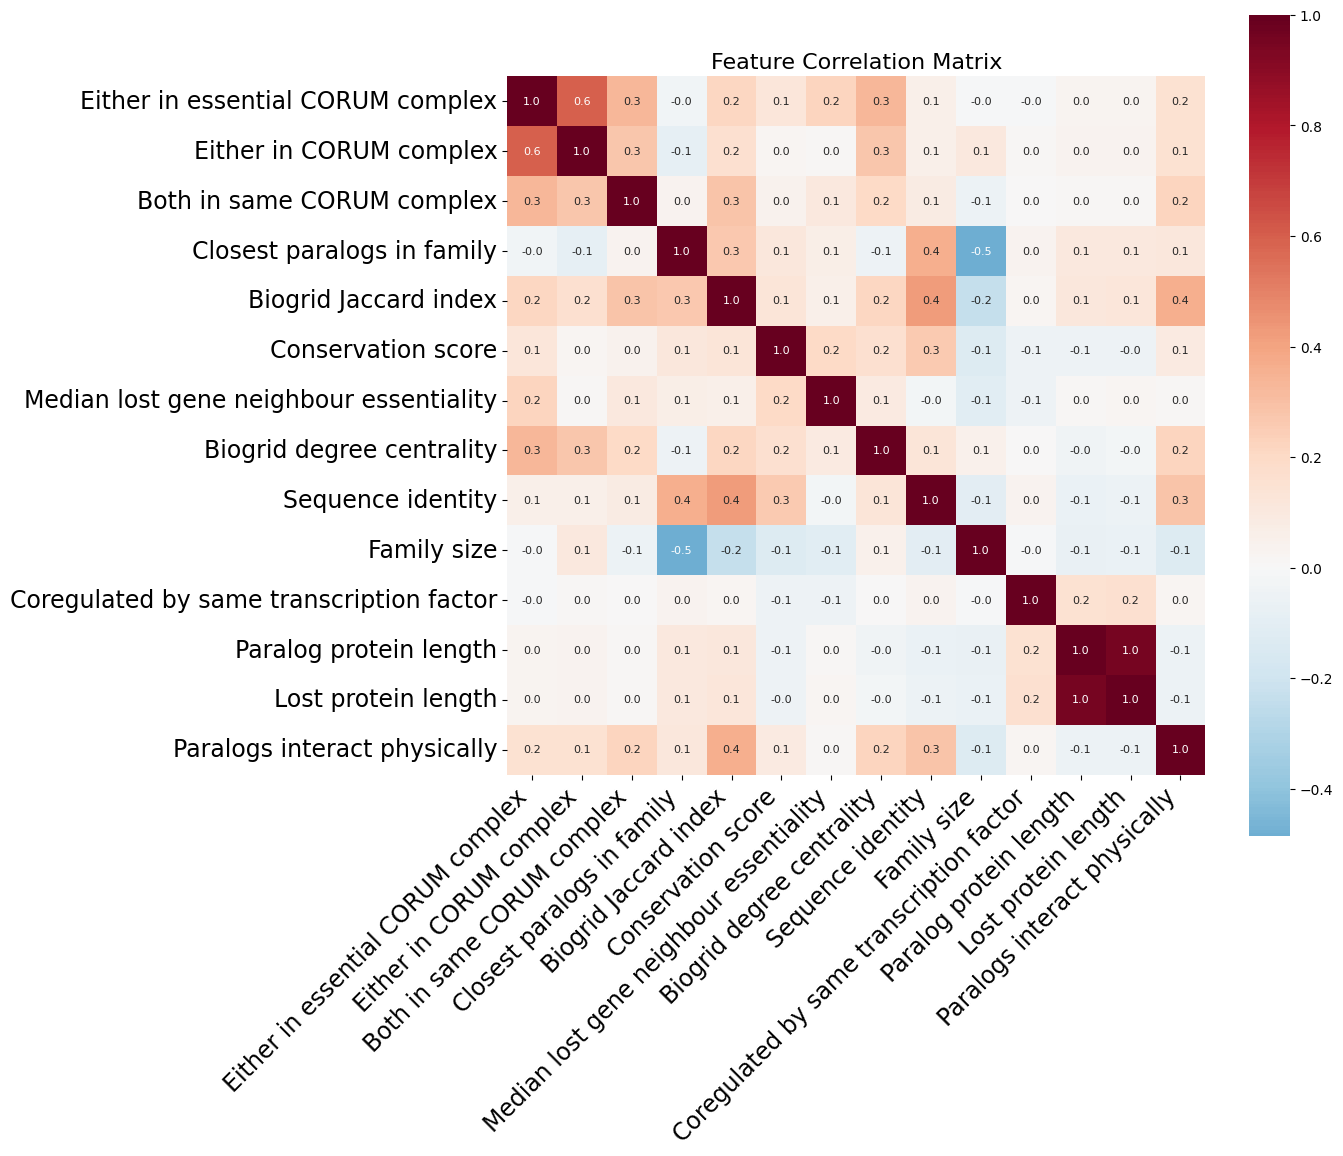

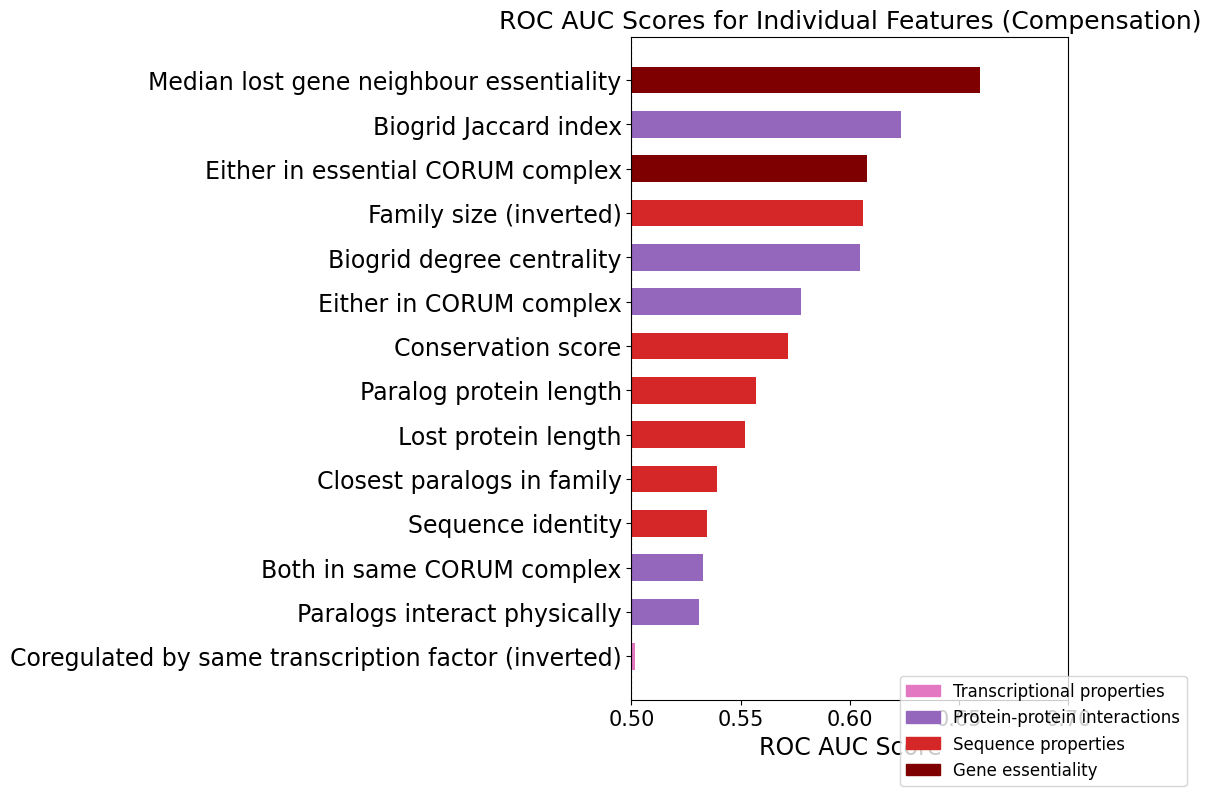

In [2]:
# Correlation Heatmap

correlation_matrix_renamed = correlation_matrix.copy()
correlation_matrix_renamed.columns = [namedict.get(col, col) for col in correlation_matrix.columns]
correlation_matrix_renamed.index = [namedict.get(idx, idx) for idx in correlation_matrix.index]

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix_renamed, annot=True, cmap='RdBu_r', center=0, 
            fmt='.1f', square=True, annot_kws={"size": 8})
plt.xticks(rotation=45, ha='right', fontsize=17)
plt.yticks(fontsize=17)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.savefig('../output/figures/corr_heatmap.svg', dpi=200, bbox_inches='tight')
plt.show()

# AUC Bar Chart for Compensation

sorted_aucs = dict(sorted(auc_scores.items(), key=lambda x: x[1], reverse=False))

renamed_sorted_aucs = {}
for k, v in sorted_aucs.items():
    renamed_key = namedict.get(k, k)
    if k in flipped_features:
        renamed_key += " (inverted)"
    renamed_sorted_aucs[renamed_key] = v

plt.figure(figsize=(12, max(8, len(renamed_sorted_aucs)*0.4)))  

feature_colors = []
feature_groups_present = set() 

for feature in sorted_aucs.keys():
    assigned_group = None
    for group_name, features in feature_groups.items():
        if feature in features:
            assigned_group = group_name
            feature_groups_present.add(group_name)
            break
    
    if assigned_group is not None:
        color = custom_colors[assigned_group]
        feature_colors.append(color)

y_pos = range(len(renamed_sorted_aucs))
bars = plt.barh(y_pos, list(renamed_sorted_aucs.values()), color=feature_colors, height=0.6)
plt.axvline(x=0.5, color='black', linestyle=':', alpha=1)
plt.yticks(y_pos, list(renamed_sorted_aucs.keys()), fontsize=17)
plt.xticks([0.5, 0.55, 0.6, 0.65, 0.7], fontsize=15)
plt.xlabel('ROC AUC Score', fontsize=17)
plt.title('ROC AUC Scores for Individual Features (Compensation)', fontsize=18)
plt.xlim(0.5, 0.7)

legend_patches = []
for group_name in feature_groups_present:
    patch = mpatches.Patch(color=custom_colors[group_name], label=group_name)
    legend_patches.append(patch)

plt.legend(handles=legend_patches, loc='lower right', fontsize=12, 
           bbox_to_anchor=(1, 0), bbox_transform=plt.gcf().transFigure)

plt.tight_layout()
plt.savefig('../output/figures/AUC_bar_filtered_features.svg', dpi=200, bbox_inches='tight')
plt.show()


In [3]:
auc_scores

{'either_in_essential_CORUM_complex': 0.6076335030757243,
 'either_in_CORUM_complex': 0.5774700044437862,
 'both_in_same_CORUM_complex': 0.5327064143600181,
 'closest_paralogs_in_family': 0.539215297721284,
 'bg_jaccard': 0.6232895510587061,
 'conservation_score': 0.5716130745401771,
 'A2_median_neighbour_ess': 0.6597479179351108,
 'biogrid_dc': 0.6047519777820602,
 'sequence_identity': 0.5346674764893,
 'family_size': 0.6061336633393591,
 'coreg_tf': 0.5016122967537573,
 'A1_length': 0.5570223957902434,
 'A2_length': 0.5518035479941286,
 'direct_interaction': 0.5309269182962613}

In [4]:
# Prepare feature matrix for Compensation model

binary_cols = [col for col in feature_cols if data_comp[col].nunique() <= 2]
continuous_cols = [col for col in feature_cols if col not in binary_cols and data_comp[col].dtype != 'object']

X_raw = data_comp[feature_cols]
y = data_comp[target_col]

X_prepared = X_raw.copy()

# Flip features identified as negative predictors
for feature in flipped_features:
    if feature in X_prepared.columns:
        X_prepared[feature] = -X_prepared[feature]

# Z-score continuous features while leaving binary features as-is
for feature in continuous_cols:
    X_prepared[feature] = (X_prepared[feature] - X_prepared[feature].mean()) / X_prepared[feature].std()

print("Binary features (not standardized):", binary_cols)
print("Continuous features (standardized):", continuous_cols)

# LASSO feature selection for Compensation

lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.01, random_state=42)
lasso_model.fit(X_prepared, y)

selected_indices = np.where(lasso_model.coef_[0] != 0)[0]
selected_features = [feature_cols[i] for i in selected_indices]
selected_coefs = lasso_model.coef_[0][selected_indices]

print("\nSelected features with coefficients:")
for feature, coef in zip(selected_features, selected_coefs):
    print(f"{feature}: {coef:.4f}")

print("\nIndividual feature AUCs:")
for feature in selected_features:
    X_feat = X_prepared[feature].values.reshape(-1, 1)
    if len(np.unique(X_feat)) > 1:
        feat_auc = roc_auc_score(y, X_feat)
        print(f"{feature}: AUC = {feat_auc:.4f}")

# Build final logistic regression model for Compensation

X_selected_prepared = X_prepared[selected_features]
X_final = sm.add_constant(X_selected_prepared)
logit_model = sm.Logit(y, X_final)
result = logit_model.fit()
print("\n", result.summary())

odds_ratios = np.exp(result.params)
conf_ints = np.exp(result.conf_int())

print("\nOdds ratios and confidence intervals:")
for i, var in enumerate(result.params.index):
    if var != 'const':
        print(f"{var}: OR = {odds_ratios[i]:.4f} (95% CI: {conf_ints.iloc[i, 0]:.4f} - {conf_ints.iloc[i, 1]:.4f})")

y_pred = result.predict(X_final)
auc = roc_auc_score(y, y_pred)
print(f"\nFinal model AUC: {auc:.4f}")


Binary features (not standardized): ['either_in_essential_CORUM_complex', 'either_in_CORUM_complex', 'both_in_same_CORUM_complex', 'closest_paralogs_in_family', 'coreg_tf', 'direct_interaction']
Continuous features (standardized): ['bg_jaccard', 'conservation_score', 'A2_median_neighbour_ess', 'biogrid_dc', 'sequence_identity', 'family_size', 'A1_length', 'A2_length', 'A1_abundance', 'A2_abundance']

Selected features with coefficients:
bg_jaccard: 0.1683
A2_median_neighbour_ess: 0.2292
biogrid_dc: 0.0649
family_size: 0.0857

Individual feature AUCs:
bg_jaccard: AUC = 0.6233
A2_median_neighbour_ess: AUC = 0.6597
biogrid_dc: AUC = 0.6048
family_size: AUC = 0.6061
Optimization terminated successfully.
         Current function value: 0.362464
         Iterations 6

                            Logit Regression Results                           
Dep. Variable:      prot_compensation   No. Observations:                 4170
Model:                          Logit   Df Residuals:              

Features in this plot that were identified as negative predictors:
 - family_size -> Family size


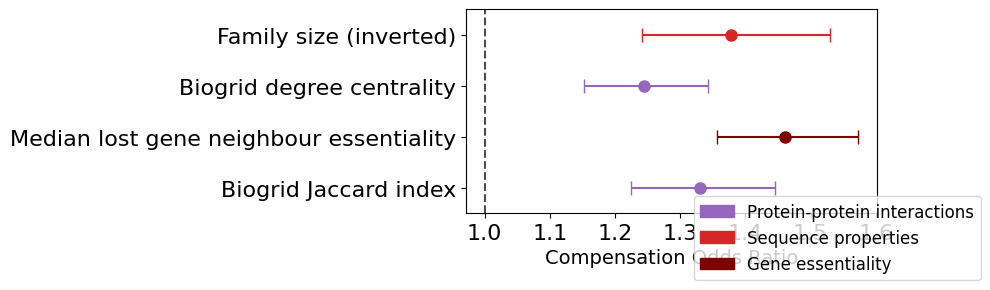



===== COMPARING FULL MODEL VS LASSO MODEL =====
Original observations: 4170
Complete observations used for comparison: 4170 (100.0%)


Binary features in full model (not standardized): ['either_in_essential_CORUM_complex', 'either_in_CORUM_complex', 'both_in_same_CORUM_complex', 'closest_paralogs_in_family', 'coreg_tf', 'direct_interaction']
Continuous features in full model (standardized): ['bg_jaccard', 'conservation_score', 'A2_median_neighbour_ess', 'biogrid_dc', 'sequence_identity', 'family_size', 'A1_length', 'A2_length', 'A1_abundance', 'A2_abundance']
Binary features in selected model (not standardized): []
Continuous features in selected model (standardized): ['bg_jaccard', 'A2_median_neighbour_ess', 'biogrid_dc', 'family_size']
Fitting full logistic regression model...
Fitting selected features model...


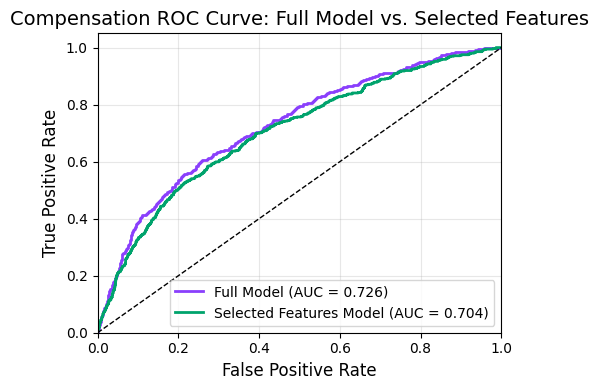

In [5]:
# Plot Odds Ratios for Compensation

plt.figure(figsize=(10, 3))  

odds_ratios = np.exp(result.params)
conf_ints = np.exp(result.conf_int())

feature_params = [param for param in result.params.index if param != 'const']
y_pos = np.arange(len(feature_params))
feature_to_group = {}
feature_colors = {}
for feature in selected_features:
    assigned_group = None
    for group_name, features in feature_groups.items():
        if feature in features:
            assigned_group = group_name
            break
    if assigned_group:
        feature_to_group[feature] = assigned_group
        feature_colors[feature] = custom_colors[assigned_group]
renamed_features = []
for feat in feature_params:
    base_name = namedict.get(feat, feat)
    if feat in flipped_features:
        renamed_features.append(f"{base_name} (inverted)")
    else:
        renamed_features.append(base_name)

for i, feature in enumerate(feature_params):
    color = feature_colors.get(feature)
    lower_err = max(0, odds_ratios[feature] - conf_ints.loc[feature, 0])
    upper_err = conf_ints.loc[feature, 1] - odds_ratios[feature]
    
    plt.errorbar(odds_ratios[feature], i, 
                 xerr=[[lower_err], [upper_err]], 
                 fmt='o', capsize=5, color=color, markersize=8)

plt.axvline(x=1, color='black', linestyle='--', alpha=0.7)
plt.yticks(y_pos, renamed_features, fontsize=16)
plt.xticks(fontsize=16)
plt.xlabel('Compensation Odds Ratio', fontsize=14)
plt.title('', fontsize=16)
plt.ylim(-0.5, len(feature_params) - 0.5)  

legend_patches = []
groups_in_plot = set(feature_to_group.values())
for group_name in groups_in_plot:
    patch = mpatches.Patch(color=custom_colors[group_name], label=group_name)
    legend_patches.append(patch)
plt.legend(handles=legend_patches, loc='lower right', fontsize=12, 
           bbox_to_anchor=(1, 0), bbox_transform=plt.gcf().transFigure)

plt.tight_layout(pad=1.5) 

flipped_in_plot = [f for f in feature_params if f in flipped_features]
if flipped_in_plot:
    print("Features in this plot that were identified as negative predictors:")
    for feat in flipped_in_plot:
        print(f" - {feat} -> {namedict.get(feat, feat)}")

plt.savefig('../output/figures/ORplot_compensation_selected_features.svg', dpi=200, bbox_inches='tight')
plt.show()

# Comparing Full vs LASSO Model 

print("\n\n===== COMPARING FULL MODEL VS LASSO MODEL =====")

# Start with ensuring we have complete observations across all models
# This ensures a fair comparison by using the same observations for all models
df = data_comp.copy()
mask_all = df[feature_cols].notna().all(axis=1)
mask_selected = df[selected_features].notna().all(axis=1)
mask_target = df[target_col].notna()

complete_mask = mask_all & mask_selected & mask_target

df_complete = df[complete_mask]

print(f"Original observations: {len(df)}")
print(f"Complete observations used for comparison: {len(df_complete)} ({len(df_complete)/len(df)*100:.1f}%)")

X_all = df_complete[feature_cols].copy()
X_selected = df_complete[selected_features].copy()
y = df_complete[target_col].astype(float)

# Identify binary and continuous columns in the full feature set
binary_cols_all = [col for col in feature_cols if df_complete[col].nunique() <= 2]
continuous_cols_all = [col for col in feature_cols if col not in binary_cols_all]

# Identify binary and continuous columns in the selected feature set
binary_cols_selected = [col for col in selected_features if df_complete[col].nunique() <= 2]
continuous_cols_selected = [col for col in selected_features if col not in binary_cols_selected]

# Standardize only continuous features in full model, leaving binary features as-is
for feature in continuous_cols_all:
    X_all[feature] = (X_all[feature] - X_all[feature].mean()) / X_all[feature].std()

# Standardize only continuous features in selected model, leaving binary features as-is
for feature in continuous_cols_selected:
    X_selected[feature] = (X_selected[feature] - X_selected[feature].mean()) / X_selected[feature].std()

print(f"Binary features in full model (not standardized): {binary_cols_all}")
print(f"Continuous features in full model (standardized): {continuous_cols_all}")
print(f"Binary features in selected model (not standardized): {binary_cols_selected}")
print(f"Continuous features in selected model (standardized): {continuous_cols_selected}")

# Train full model with selectively standardized features
print("Fitting full logistic regression model...")
full_model = LogisticRegression(max_iter=1000, random_state=42)
full_model.fit(X_all, y)

# Get predictions for full model
y_pred_full = full_model.predict_proba(X_all)[:, 1]
full_auc = roc_auc_score(y, y_pred_full)

# Train selected model on the same observations with selectively standardized features
print("Fitting selected features model...")
selected_model = LogisticRegression(max_iter=1000, random_state=42)
selected_model.fit(X_selected, y)
y_pred_selected = selected_model.predict_proba(X_selected)[:, 1]
selected_auc = roc_auc_score(y, y_pred_selected)

viridis_purple = '#8A3FFC'
viridis_green = '#00A36C' 

plt.figure(figsize=(5, 4))

fpr_full, tpr_full, _ = roc_curve(y, y_pred_full)
roc_auc_full = sklearn_auc(fpr_full, tpr_full)
plt.plot(fpr_full, tpr_full, color=viridis_purple, lw=2, 
         label=f'Full Model (AUC = {roc_auc_full:.3f})')

fpr_selected, tpr_selected, _ = roc_curve(y, y_pred_selected)
roc_auc_selected = sklearn_auc(fpr_selected, tpr_selected)
plt.plot(fpr_selected, tpr_selected, color=viridis_green, lw=2, 
         label=f'Selected Features Model (AUC = {roc_auc_selected:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Compensation ROC Curve: Full Model vs. Selected Features', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../output/figures/ROC_comparison_standardized.svg', dpi=200, bbox_inches='tight')
plt.show()



===== COMPARING MODELS WITH ADDITIONAL FEATURE: SL_atleast1_CRISPRscreen =====
Augmented feature list created with 5 features
Original observations: 1727
Complete observations across all models: 1727 (100.0%)
Standardized continuous features while keeping binary features unchanged
Fitting selected features model...
Fitting augmented model (selected features + SL_atleast1_CRISPRscreen)...
Fitting full logistic regression model...


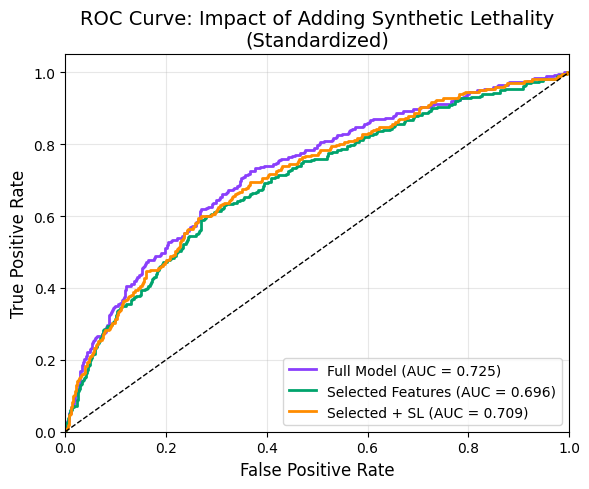


===== MODEL COMPARISON SUMMARY (STANDARDIZED) =====

Selected Features Model (4 features):
  - AUC: 0.6959
  - Features: bg_jaccard, A2_median_neighbour_ess, biogrid_dc, family_size

Augmented Model (Selected + SL):
  - AUC: 0.7089
  - Additional AUC gained: 0.0131

Likelihood Ratio Test Results:
  - LR statistic: 15.3630
  - p-value: 0.000089
  - Significance (α=0.05): Significant

===== CREATING ODDS RATIO PLOT WITH SYNTHETIC LETHALITY =====


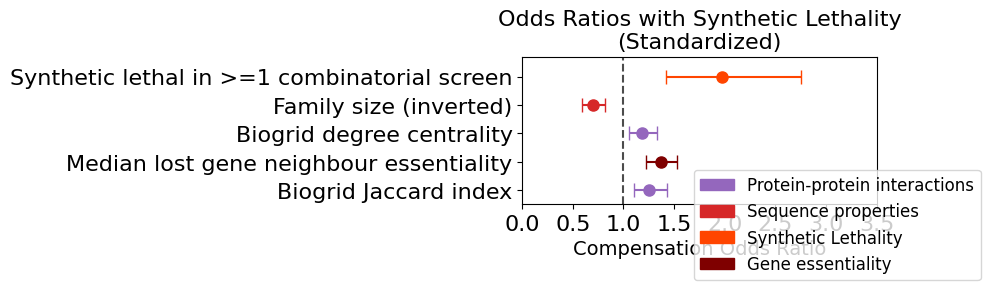


===== MODEL SUMMARY WITH SYNTHETIC LETHALITY =====
Number of observations: 1727
Number of features: 5
Pseudo R-squared: 0.0866

Features with odds ratio < 1:
 - family_size -> Family size


In [6]:
# ## Add Synthetic Lethality to Compensation Model

data_comp_wSL = data_clean[~data_clean['prot_collateral_loss']].copy()
columns_to_drop_wSL = [
    'depmap_SL', 'SL_atleast2_CRISPR_screens',  
    'gene_pair', 'sorted_gene_pair', 'CPTAC_hit_type',
    'A1', 'A2', 'trans_compensation', 'trans_collateral_loss',
    'either_in_EBIComplexPortal_complex', 'either_in_humap_complex',
    'string_jaccard_physical', 'string_dc_physical',
    'prot_collateral_loss', 'A1_dis', 'A2_dis', 'A1_hl', 'A2_hl', 'A1_perc_at_int', 'A2_perc_at_int',
    'resid_compensation', 'resid_collateral_loss', 'other_dir_prot_compensation',
    'other_dir_prot_collateral_loss', 'other_dir_trans_compensation',
    'other_dir_trans_collateral_loss', 'other_dir_resid_compensation',
    'other_dir_resid_collateral_loss', 'A1_regulates_A2',
    'A2_regulates_A1', 'either_regulates_other', 
    'n_SL_thompson', 'n_SL_dede', 'n_SL_parrish', 'n_SL_chymera', 'n_SL_ito',
    'A1_interface_residues', 'A2_interface_residues'
]

columns_to_drop_wSL = [col for col in columns_to_drop_wSL if col in data_comp_wSL.columns]
data_comp_wSL = data_comp_wSL.drop(columns_to_drop_wSL, axis=1)
data_comp_wSL = data_comp_wSL.dropna()
target_col_wSL = 'prot_compensation'
feature_cols_wSL = [col for col in data_comp_wSL.columns if col != target_col_wSL]

print("\n\n===== COMPARING MODELS WITH ADDITIONAL FEATURE: SL_atleast1_CRISPRscreen =====")

augmented_features = selected_features + ['SL_atleast1_CRISPRscreen']
print(f"Augmented feature list created with {len(augmented_features)} features")
mask_selected = data_comp_wSL[selected_features].notna().all(axis=1)
mask_augmented = data_comp_wSL[augmented_features].notna().all(axis=1)
mask_target = data_comp_wSL[target_col_wSL].notna()
complete_mask = mask_selected & mask_augmented & mask_target
df_complete = data_comp_wSL[complete_mask]

print(f"Original observations: {len(data_comp_wSL)}")
print(f"Complete observations across all models: {len(df_complete)} ({len(df_complete)/len(data_comp_wSL)*100:.1f}%)")

X_selected_raw = df_complete[selected_features].astype(float)
X_augmented_raw = df_complete[augmented_features].astype(float)
y = df_complete[target_col_wSL].astype(float)
binary_cols_selected = [col for col in selected_features if df_complete[col].nunique() <= 2]
binary_cols_augmented = [col for col in augmented_features if df_complete[col].nunique() <= 2]
continuous_cols_selected = [col for col in selected_features if col not in binary_cols_selected]
continuous_cols_augmented = [col for col in augmented_features if col not in binary_cols_augmented]

X_selected = X_selected_raw.copy()
X_augmented = X_augmented_raw.copy()

# Standardize continuous features (z-score)
for feature in continuous_cols_selected:
    X_selected[feature] = (X_selected[feature] - X_selected[feature].mean()) / X_selected[feature].std()
    
for feature in continuous_cols_augmented:
    X_augmented[feature] = (X_augmented[feature] - X_augmented[feature].mean()) / X_augmented[feature].std()

print("Standardized continuous features while keeping binary features unchanged")

# Train selected model
print("Fitting selected features model...")
selected_model = LogisticRegression(max_iter=1000, random_state=42)
selected_model.fit(X_selected, y)
y_pred_selected = selected_model.predict_proba(X_selected)[:, 1]
selected_auc = roc_auc_score(y, y_pred_selected)

print("Fitting augmented model (selected features + SL_atleast1_CRISPRscreen)...")
augmented_model = LogisticRegression(max_iter=1000, random_state=42)
augmented_model.fit(X_augmented, y)
y_pred_augmented = augmented_model.predict_proba(X_augmented)[:, 1]
augmented_auc = roc_auc_score(y, y_pred_augmented)

# Perform Likelihood Ratio Test (LRT) using statsmodels
X_selected_sm = sm.add_constant(X_selected)
X_augmented_sm = sm.add_constant(X_augmented)

model_selected = sm.Logit(y, X_selected_sm).fit(disp=0)
model_augmented = sm.Logit(y, X_augmented_sm).fit(disp=0)
lr_stat = 2 * (model_augmented.llf - model_selected.llf)
p_value = stats.chi2.sf(lr_stat, df=1)  # df=1 because we added 1 feature

print("Fitting full logistic regression model...")
full_model = LogisticRegression(max_iter=1000, random_state=42)
X_all = df_complete[feature_cols_wSL].astype(float)
binary_cols_all = [col for col in feature_cols_wSL if df_complete[col].nunique() <= 2]
continuous_cols_all = [col for col in feature_cols_wSL if col not in binary_cols_all]
X_all_prepared = X_all.copy()
for feature in continuous_cols_all:
    X_all_prepared[feature] = (X_all_prepared[feature] - X_all_prepared[feature].mean()) / X_all_prepared[feature].std()
full_model.fit(X_all_prepared, y)
y_pred_full = full_model.predict_proba(X_all_prepared)[:, 1]
full_auc = roc_auc_score(y, y_pred_full)

viridis_purple = '#8A3FFC' 
viridis_green = '#00A36C'   
viridis_orange = '#FF8C00' 

plt.figure(figsize=(6, 5))

fpr_full, tpr_full, _ = roc_curve(y, y_pred_full)
roc_auc_full = sklearn_auc(fpr_full, tpr_full)
plt.plot(fpr_full, tpr_full, color=viridis_purple, lw=2, 
         label=f'Full Model (AUC = {roc_auc_full:.3f})')

fpr_selected, tpr_selected, _ = roc_curve(y, y_pred_selected)
roc_auc_selected = sklearn_auc(fpr_selected, tpr_selected)
plt.plot(fpr_selected, tpr_selected, color=viridis_green, lw=2, 
         label=f'Selected Features (AUC = {roc_auc_selected:.3f})')

fpr_augmented, tpr_augmented, _ = roc_curve(y, y_pred_augmented)
roc_auc_augmented = sklearn_auc(fpr_augmented, tpr_augmented)
plt.plot(fpr_augmented, tpr_augmented, color=viridis_orange, lw=2, 
         label=f'Selected + SL (AUC = {roc_auc_augmented:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve: Impact of Adding Synthetic Lethality\n(Standardized)', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../output/figures/ROC_comparison_SL_atleast1_CRISPRscreen_standardized.svg', dpi=200, bbox_inches='tight')
plt.show()

print("\n===== MODEL COMPARISON SUMMARY (STANDARDIZED) =====")
print(f"\nSelected Features Model ({len(selected_features)} features):")
print(f"  - AUC: {selected_auc:.4f}")
print(f"  - Features: {', '.join(selected_features)}")

print(f"\nAugmented Model (Selected + SL):")
print(f"  - AUC: {augmented_auc:.4f}")
print(f"  - Additional AUC gained: {augmented_auc - selected_auc:.4f}")

print(f"\nLikelihood Ratio Test Results:")
print(f"  - LR statistic: {lr_stat:.4f}")
print(f"  - p-value: {p_value:.6f}")
sig_status = "Significant" if p_value < 0.05 else "Not significant"
print(f"  - Significance (α=0.05): {sig_status}")

print("\n===== CREATING ODDS RATIO PLOT WITH SYNTHETIC LETHALITY =====")

X_augmented_for_plot = sm.add_constant(X_augmented)
augmented_result = sm.Logit(y, X_augmented_for_plot).fit(disp=0)
odds_ratios = np.exp(augmented_result.params)
conf_ints = np.exp(augmented_result.conf_int())
feature_params = [param for param in augmented_result.params.index if param != 'const']
y_pos = np.arange(len(feature_params))

fig_height = max(3, len(feature_params) * 0.4)  # Adjust height based on feature count
plt.figure(figsize=(10, fig_height))

feature_to_group = {}
feature_colors = {}

for feature in augmented_features:
    assigned_group = None
    for group_name, features in feature_groups.items():
        if feature in features:
            assigned_group = group_name
            break
    if assigned_group:
        feature_to_group[feature] = assigned_group
        feature_colors[feature] = custom_colors[assigned_group]
    else:
        feature_to_group[feature] = "Other"
        feature_colors[feature] = "#808080" 

feature_colors['SL_atleast1_CRISPRscreen'] = "#FF4500" 
feature_to_group['SL_atleast1_CRISPRscreen'] = "Synthetic Lethality"

flipped_features_new = [feat for feat in feature_params if odds_ratios[feat] < 1]

renamed_features = []
for feat in feature_params:
    base_name = namedict.get(feat, feat)
    if feat in flipped_features_new:
        renamed_features.append(f"{base_name} (inverted)")
    else:
        renamed_features.append(base_name)
    
for i, feature in enumerate(feature_params):
    color = feature_colors.get(feature)
    lower_err = max(0, odds_ratios[feature] - conf_ints.loc[feature, 0])
    upper_err = conf_ints.loc[feature, 1] - odds_ratios[feature]    
    plt.errorbar(odds_ratios[feature], i, 
                     xerr=[[lower_err], [upper_err]], 
                     fmt='o', capsize=5, color=color, markersize=8)

plt.axvline(x=1, color='black', linestyle='--', alpha=0.7)

plt.yticks(y_pos, renamed_features, fontsize=16)
plt.xticks(fontsize=16)
plt.xlabel('Compensation Odds Ratio', fontsize=14)
plt.title('Odds Ratios with Synthetic Lethality\n(Standardized)', fontsize=16)

plt.ylim(-0.5, len(feature_params) - 0.3)
plt.xlim(0, 3.5)

legend_patches = []
for group_name in set(feature_to_group.values()):
    if group_name == "Synthetic Lethality":
        patch = mpatches.Patch(color="#FF4500", label="Synthetic Lethality")
    else:
        patch = mpatches.Patch(color=custom_colors.get(group_name, "#808080"), label=group_name)
    legend_patches.append(patch)

plt.legend(handles=legend_patches, loc='lower right', fontsize=12, 
           bbox_to_anchor=(1, 0), bbox_transform=plt.gcf().transFigure)

plt.tight_layout(pad=1.5, rect=[0, 0.03, 1, 1])  
plt.savefig('../output/figures/ORplot_with_SL_standardized.svg', dpi=200, bbox_inches='tight')
plt.show()

print("\n===== MODEL SUMMARY WITH SYNTHETIC LETHALITY =====")
print(f"Number of observations: {len(df_complete)}")
print(f"Number of features: {len(augmented_features)}")
print(f"Pseudo R-squared: {augmented_result.prsquared:.4f}")

if flipped_features_new:
    print("\nFeatures with odds ratio < 1:")
    for feat in flipped_features_new:
        print(f" - {feat} -> {namedict.get(feat, feat)}")

Collateral loss data shape after cleaning: (4386, 14)
Target distribution: prot_collateral_loss
0    3863
1     523
Name: count, dtype: int64
Features identified as negative predictors (flipped for collateral loss):
 - either_in_essential_CORUM_complex
 - either_in_CORUM_complex
 - both_in_same_CORUM_complex
 - closest_paralogs_in_family
 - bg_jaccard
 - conservation_score
 - A2_median_neighbour_ess
 - biogrid_dc
 - sequence_identity
 - direct_interaction


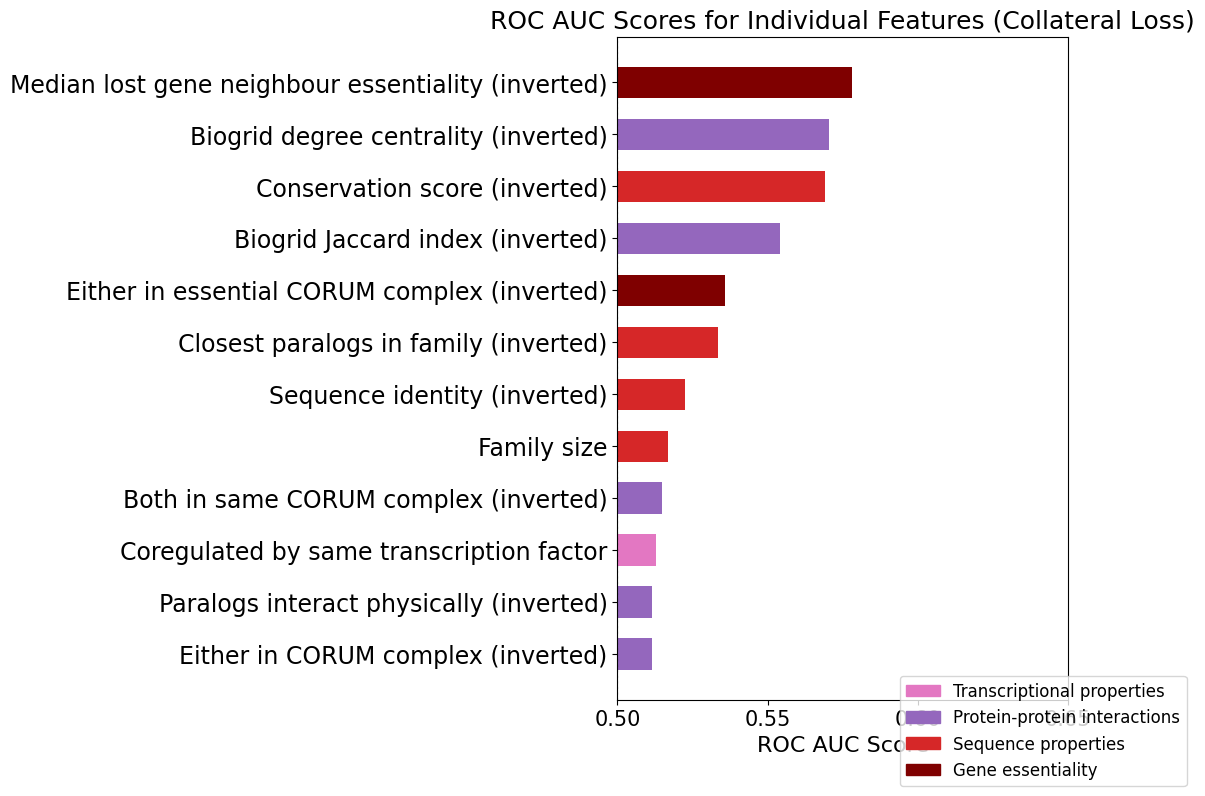

Binary features (not standardized): ['either_in_essential_CORUM_complex', 'either_in_CORUM_complex', 'both_in_same_CORUM_complex', 'closest_paralogs_in_family', 'coreg_tf', 'direct_interaction']
Continuous features (standardized): ['bg_jaccard', 'conservation_score', 'A2_median_neighbour_ess', 'biogrid_dc', 'sequence_identity', 'family_size', 'mean_length']

Selected features with coefficients (Collateral Loss):
A2_median_neighbour_ess: 0.0240
biogrid_dc: 0.0190

Individual feature AUCs (Collateral Loss):
A2_median_neighbour_ess: AUC = 0.5780
biogrid_dc: AUC = 0.5704
Optimization terminated successfully.
         Current function value: 0.358190
         Iterations 7

                             Logit Regression Results                            
Dep. Variable:     prot_collateral_loss   No. Observations:                 4386
Model:                            Logit   Df Residuals:                     4383
Method:                             MLE   Df Model:                            

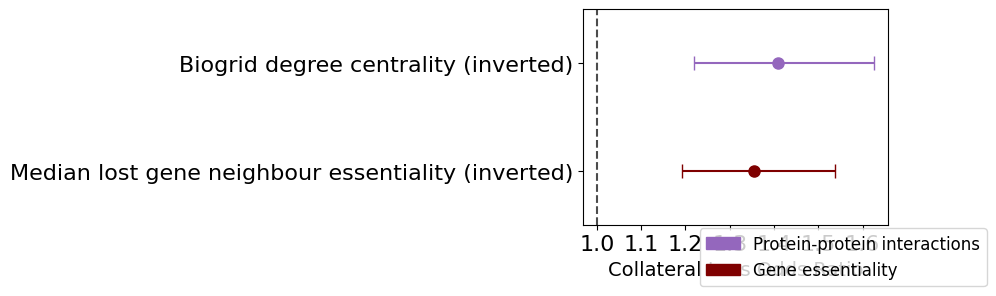

In [7]:

# Data preparation for collateral loss

data_cl = data_clean[~data_clean['prot_compensation']].copy()
data_cl['mean_length'] = data_cl.apply(lambda x: (x['A1_length'] + x['A2_length'])/2, axis=1)

columns_to_drop_cl = [
    'depmap_SL', 'SL_atleast2_CRISPR_screens', 'SL_atleast1_CRISPRscreen',
    'A1_hl', 'A2_hl', 'gene_pair', 'sorted_gene_pair', 'CPTAC_hit_type',
    'A1', 'A2', 'trans_compensation', 'trans_collateral_loss',
    'either_in_EBIComplexPortal_complex', 'either_in_humap_complex',
    'string_jaccard_physical', 'string_dc_physical',
    'prot_compensation', 'A1_perc_at_int', 'A2_perc_at_int',
    'resid_compensation', 'resid_collateral_loss', 'other_dir_prot_compensation',
    'other_dir_prot_collateral_loss', 'other_dir_trans_compensation',
    'other_dir_trans_collateral_loss','other_dir_resid_compensation',
    'other_dir_resid_collateral_loss', 'A1_regulates_A2',
    'A2_regulates_A1', 'either_regulates_other', 
    'n_SL_thompson', 'n_SL_dede', 'n_SL_parrish', 'n_SL_chymera', 'n_SL_ito',
    'A1_interface_residues', 'A2_interface_residues', 
    'A1_abundance', 'A2_abundance', 'A1_dis', 'A2_dis', 'A1_length', 'A2_length'
]

columns_to_drop_cl = [col for col in columns_to_drop_cl if col in data_cl.columns]
data_cl = data_cl.drop(columns_to_drop_cl, axis=1)

target_col_cl = 'prot_collateral_loss'
feature_cols_cl = [col for col in data_cl.columns if col != target_col_cl]

data_cl[target_col_cl] = data_cl[target_col_cl].map({True: 1, False: 0})

data_cl = data_cl.dropna()
print(f"Collateral loss data shape after cleaning: {data_cl.shape}")
print(f"Target distribution: {data_cl[target_col_cl].value_counts()}")

all_grouped_features = []
for features in feature_groups.values():
    all_grouped_features.extend(features)

relevant_feature_cols_cl = [col for col in feature_cols_cl if col in all_grouped_features]

auc_scores_cl = {}
flipped_features_cl = []

for feature in relevant_feature_cols_cl:
    feature_data = data_cl[[feature, target_col_cl]].dropna()
    if len(feature_data) > 0:
        X_feat = feature_data[feature].values.reshape(-1, 1)
        y_feat = feature_data[target_col_cl].values
        if len(X_feat) > 0 and len(np.unique(X_feat)) > 1 and len(np.unique(y_feat)) > 1:
            try:
                auc = roc_auc_score(y_feat, X_feat)
                # Check if this is a negative predictor (AUC < 0.5)
                if auc < 0.5:
                    flipped_features_cl.append(feature)
                    auc = roc_auc_score(y_feat, -1 * X_feat)
                auc_scores_cl[feature] = auc
            except Exception as e:
                print(f"Error calculating AUC for {feature}: {e}")
                
if flipped_features_cl:
    print("Features identified as negative predictors (flipped for collateral loss):")
    for feat in flipped_features_cl:
        print(f" - {feat}")

sorted_aucs_cl = dict(sorted(auc_scores_cl.items(), key=lambda x: x[1], reverse=False))
renamed_sorted_aucs_cl = {}
for k, v in sorted_aucs_cl.items():
    renamed_key = namedict.get(k, k)
    if k in flipped_features_cl:
        renamed_key += " (inverted)"
    renamed_sorted_aucs_cl[renamed_key] = v


plt.figure(figsize=(12, max(8, len(renamed_sorted_aucs_cl)*0.4))) 
feature_colors_cl = []
feature_groups_present = set() 
for feature in sorted_aucs_cl.keys():
    assigned_group = None
    for group_name, features in feature_groups.items():
        if feature in features:
            assigned_group = group_name
            feature_groups_present.add(group_name)
            break
    
    if assigned_group is not None:
        color = custom_colors[assigned_group]
        feature_colors_cl.append(color)

y_pos = range(len(renamed_sorted_aucs_cl))
bars = plt.barh(y_pos, list(renamed_sorted_aucs_cl.values()), color=feature_colors_cl, height=0.6)

plt.axvline(x=0.5, color='black', linestyle=':', alpha=1)

plt.yticks(y_pos, list(renamed_sorted_aucs_cl.keys()), fontsize=17)
plt.xticks([0.5, 0.55, 0.6, 0.65], fontsize=15)
plt.xlabel('ROC AUC Score', fontsize=16)
plt.title('ROC AUC Scores for Individual Features (Collateral Loss)', fontsize=18)
plt.xlim(0.5, 0.65)

legend_patches = []
for group_name in feature_groups_present:
    patch = mpatches.Patch(color=custom_colors[group_name], label=group_name)
    legend_patches.append(patch)

plt.legend(handles=legend_patches, loc='lower right', fontsize=12, 
           bbox_to_anchor=(1, 0), bbox_transform=plt.gcf().transFigure)

plt.tight_layout()
plt.savefig('../output/figures/AUC_bar_filtered_features_collateral_loss.svg', dpi=200, bbox_inches='tight')
plt.show()

binary_cols_cl = [col for col in feature_cols_cl if data_cl[col].nunique() <= 2]
continuous_cols_cl = [col for col in feature_cols_cl if col not in binary_cols_cl and data_cl[col].dtype != 'object']

X_raw_cl = data_cl[feature_cols_cl]
y_cl = data_cl[target_col_cl]

X_prepared_cl = X_raw_cl.copy()

for feature in flipped_features_cl:
    if feature in X_prepared_cl.columns:
        X_prepared_cl[feature] = -X_prepared_cl[feature]

for feature in continuous_cols_cl:
    X_prepared_cl[feature] = (X_prepared_cl[feature] - X_prepared_cl[feature].mean()) / X_prepared_cl[feature].std()

print("Binary features (not standardized):", binary_cols_cl)
print("Continuous features (standardized):", continuous_cols_cl)

# Train LASSO model for feature selection

lasso_model_cl = LogisticRegression(penalty='l1', solver='liblinear', C=0.01, random_state=42)
lasso_model_cl.fit(X_prepared_cl, y_cl)

selected_indices_cl = np.where(lasso_model_cl.coef_[0] != 0)[0]
selected_features_cl = [feature_cols_cl[i] for i in selected_indices_cl]
selected_coefs_cl = lasso_model_cl.coef_[0][selected_indices_cl]

print("\nSelected features with coefficients (Collateral Loss):")
for feature, coef in zip(selected_features_cl, selected_coefs_cl):
    print(f"{feature}: {coef:.4f}")

print("\nIndividual feature AUCs (Collateral Loss):")
for feature in selected_features_cl:
    X_feat_cl = X_prepared_cl[feature].values.reshape(-1, 1)
    if len(np.unique(X_feat_cl)) > 1:
        feat_auc_cl = roc_auc_score(y_cl, X_feat_cl)
        print(f"{feature}: AUC = {feat_auc_cl:.4f}")

# Extract only selected features for final model
X_selected_prepared_cl = X_prepared_cl[selected_features_cl]

# Build final logistic regression with selected features
X_final_cl = sm.add_constant(X_selected_prepared_cl)
logit_model_cl = sm.Logit(y_cl, X_final_cl)
result_cl = logit_model_cl.fit()
print("\n", result_cl.summary())

odds_ratios_cl = np.exp(result_cl.params)
conf_ints_cl = np.exp(result_cl.conf_int())

print("\nOdds ratios and confidence intervals (Collateral Loss):")
for i, var in enumerate(result_cl.params.index):
    if var != 'const':
        print(f"{var}: OR = {odds_ratios_cl[i]:.4f} (95% CI: {conf_ints_cl.iloc[i, 0]:.4f} - {conf_ints_cl.iloc[i, 1]:.4f})")

# Calculate AUC for final model
y_pred_cl = result_cl.predict(X_final_cl)
auc_cl = roc_auc_score(y_cl, y_pred_cl)
print(f"\nFinal model AUC (Collateral Loss): {auc_cl:.4f}")

# Plot Odds Ratios for Collateral Loss

plt.figure(figsize=(10, 3))  

odds_ratios_cl = np.exp(result_cl.params)
conf_ints_cl = np.exp(result_cl.conf_int())

feature_params_cl = [param for param in result_cl.params.index if param != 'const']
y_pos_cl = np.arange(len(feature_params_cl))

feature_to_group_cl = {}
feature_colors_cl = {}
for feature in selected_features_cl:
    assigned_group = None
    for group_name, features in feature_groups.items():
        if feature in features:
            assigned_group = group_name
            break
    if assigned_group:
        feature_to_group_cl[feature] = assigned_group
        feature_colors_cl[feature] = custom_colors[assigned_group]

renamed_features_cl = []
for feat in feature_params_cl:
    base_name = namedict.get(feat, feat)
    if feat in flipped_features_cl:
        renamed_features_cl.append(f"{base_name} (inverted)")
    else:
        renamed_features_cl.append(base_name)

for i, feature in enumerate(feature_params_cl):
    color = feature_colors_cl.get(feature)
    lower_err = max(0, odds_ratios_cl[feature] - conf_ints_cl.loc[feature, 0])
    upper_err = conf_ints_cl.loc[feature, 1] - odds_ratios_cl[feature]
    
    plt.errorbar(odds_ratios_cl[feature], i, 
                 xerr=[[lower_err], [upper_err]], 
                 fmt='o', capsize=5, color=color, markersize=8)

plt.axvline(x=1, color='black', linestyle='--', alpha=0.7)

plt.yticks(y_pos_cl, renamed_features_cl, fontsize=16)
plt.xticks(fontsize=16)
plt.xlabel('Collateral Loss Odds Ratio', fontsize=14)
plt.title('', fontsize=16)

num_features = len(feature_params_cl)
if num_features <= 2:
    y_padding = 0.5
elif num_features <= 5:
    y_padding = 0.8
else:
    y_padding = num_features * 0.15

plt.ylim(-y_padding, num_features - 1 + y_padding)

legend_patches = []
groups_in_plot_cl = set(feature_to_group_cl.values())
for group_name in groups_in_plot_cl:
    patch = mpatches.Patch(color=custom_colors[group_name], label=group_name)
    legend_patches.append(patch)

plt.legend(handles=legend_patches, loc='lower right', fontsize=12, 
           bbox_to_anchor=(1, 0), bbox_transform=plt.gcf().transFigure)

flipped_in_plot_cl = [f for f in feature_params_cl if f in flipped_features_cl]
if flipped_in_plot_cl:
    print("Features in collateral loss plot that were identified as negative predictors:")
    for feat in flipped_in_plot_cl:
        print(f" - {feat} -> {namedict.get(feat, feat)}")

plt.tight_layout()
plt.savefig('../output/figures/ORplot_collateral_loss_selected_features.svg', dpi=200, bbox_inches='tight')
plt.show()

Common features: 12
Features with valid AUCs in both datasets: 12


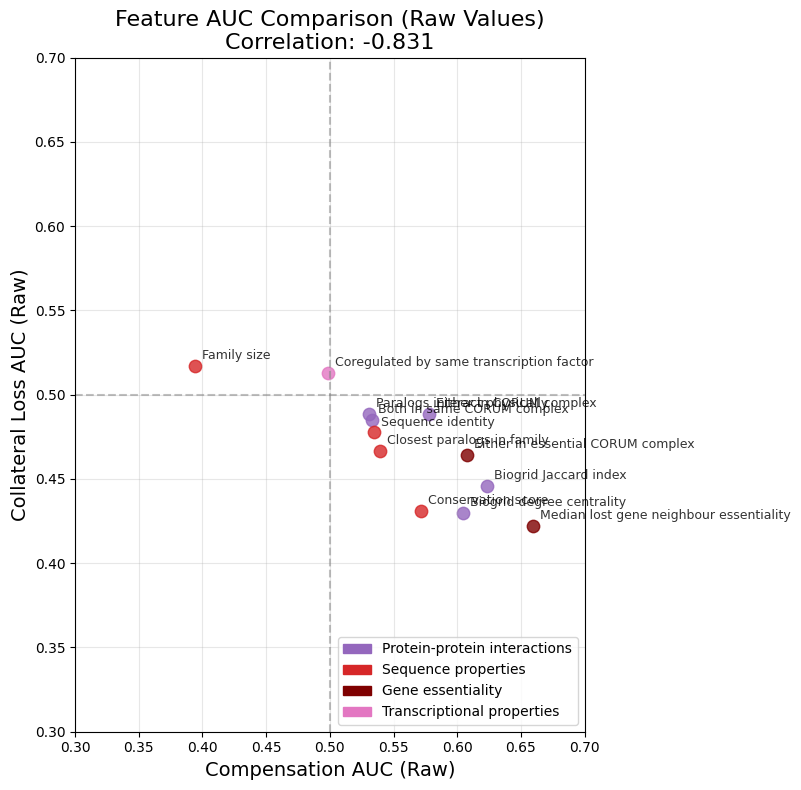

Correlation between raw AUCs: -0.831

Quadrant counts:
Q1 (Both positive): 0 features
Q2 (Compensation negative, Collateral Loss positive): 2 features
Q3 (Both negative): 0 features
Q4 (Compensation positive, Collateral Loss negative): 10 features
Opposing predictors: 12 features (100.0%)


In [8]:
# Compare Compensation vs Collateral Loss Predictors

raw_aucs_comp = {}
raw_aucs_cl = {}

common_features = [f for f in feature_cols if f in feature_cols_cl]

print(f"Common features: {len(common_features)}")

for feature in common_features:
    if feature in data_comp.columns:
        feature_data = data_comp[[feature, target_col]].dropna()
        if len(feature_data) > 0:
            X_feat = feature_data[feature].values.reshape(-1, 1)
            y_feat = feature_data[target_col].values
            if len(X_feat) > 0 and len(np.unique(X_feat)) > 1 and len(np.unique(y_feat)) > 1:
                try:
                    # Raw, unflipped AUC - this is what we want
                    auc = roc_auc_score(y_feat, X_feat)
                    raw_aucs_comp[feature] = auc
                except Exception as e:
                    print(f"Error with compensation feature {feature}: {e}")

for feature in common_features:
    if feature in data_cl.columns:
        feature_data = data_cl[[feature, target_col_cl]].dropna()
        if len(feature_data) > 0:
            X_feat = feature_data[feature].values.reshape(-1, 1)
            y_feat = feature_data[target_col_cl].values
            if len(X_feat) > 0 and len(np.unique(X_feat)) > 1 and len(np.unique(y_feat)) > 1:
                try:
                    auc = roc_auc_score(y_feat, X_feat)
                    raw_aucs_cl[feature] = auc
                except Exception as e:
                    print(f"Error with collateral loss feature {feature}: {e}")

valid_features = [f for f in raw_aucs_comp if f in raw_aucs_cl]

print(f"Features with valid AUCs in both datasets: {len(valid_features)}")


# Create scatterplot comparing raw AUC values

plt.figure(figsize=(8, 8))

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

for feature in valid_features:
    color = None
    for group_name, features in feature_groups.items():
        if feature in features:
            color = custom_colors[group_name]
            break
    if not color:
        color = "#808080"
    plt.scatter(raw_aucs_comp[feature], raw_aucs_cl[feature], 
               color=color, s=80, alpha=0.8)
    label = namedict.get(feature, feature)
    plt.annotate(label, 
                xy=(raw_aucs_comp[feature], raw_aucs_cl[feature]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, alpha=0.8)

x_values = [raw_aucs_comp[f] for f in valid_features]
y_values = [raw_aucs_cl[f] for f in valid_features]

correlation = pd.Series(x_values).corr(pd.Series(y_values), method='pearson')

# Set axis limits with padding
plt.xlim([0.3, 0.7])
plt.ylim([0.3, 0.7])

# Add labels and title
plt.xlabel('Compensation AUC (Raw)', fontsize=14)
plt.ylabel('Collateral Loss AUC (Raw)', fontsize=14)
plt.title(f'Feature AUC Comparison (Raw Values)\nCorrelation: {correlation:.3f}', fontsize=16)

# Create legend for feature groups only
legend_patches = []
for group_name in feature_groups.keys():
    patch = mpatches.Patch(color=custom_colors[group_name], label=group_name)
    legend_patches.append(patch)

plt.legend(handles=legend_patches, loc='lower right', fontsize=10)

# Show gridlines
plt.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.show()

# Print statistics
print(f"Correlation between raw AUCs: {correlation:.3f}")

# Count features in each quadrant
q1 = sum(1 for f in valid_features if raw_aucs_comp[f] > 0.5 and raw_aucs_cl[f] > 0.5)
q2 = sum(1 for f in valid_features if raw_aucs_comp[f] < 0.5 and raw_aucs_cl[f] > 0.5)
q3 = sum(1 for f in valid_features if raw_aucs_comp[f] < 0.5 and raw_aucs_cl[f] < 0.5)
q4 = sum(1 for f in valid_features if raw_aucs_comp[f] > 0.5 and raw_aucs_cl[f] < 0.5)

# Print quadrant counts
print("\nQuadrant counts:")
print(f"Q1 (Both positive): {q1} features")
print(f"Q2 (Compensation negative, Collateral Loss positive): {q2} features") 
print(f"Q3 (Both negative): {q3} features")
print(f"Q4 (Compensation positive, Collateral Loss negative): {q4} features")
print(f"Opposing predictors: {q2 + q4} features ({(q2 + q4)/len(valid_features)*100:.1f}%)")